In [1]:
!pip install roboflow tensorflow opencv-python matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 36.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 60.9 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.15
    Uninstalling idna-3.15:
      Successfully uninstalled idna-3.15


In [5]:
from roboflow import Roboflow
import cv2, json, os
import numpy as np
import tensorflow as tf
from tensorflow.keras import Sequential, layers, Input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from pathlib import Path
import yaml

# ────────────────────────────────────────────────────────────────
# 0. CONFIG
# ────────────────────────────────────────────────────────────────
IMG_SIZE = (64, 64)
BATCH    = 16
EPOCHS   = 20 # Giảm bớt số vòng lặp để nhanh hơn

ASPECT_MAP = {
    "Head-Line": "Trí tuệ",
    "Heart-Line": "Tình duyên",
    "Life-Line": "Sức khỏe",
    "Fate-Line": "Sự nghiệp"
}

RESULT_LABELS = {
    "Life-Line":  ["Sức khỏe yếu", "Sức khỏe ổn định", "Sức khỏe tốt"],
    "Heart-Line": ["Tình duyên trắc trở", "Bình thường", "Thuận lợi"],
    "Head-Line":  ["Thiên về cảm tính", "Cân bằng", "Tư duy sắc bén"],
    "Fate-Line":  ["Thử thách", "Ổn định", "Thành công"]
}

# ────────────────────────────────────────────────────────────────
# 1. TẢI DATASET TỪ ROBOFLOW
# ────────────────────────────────────────────────────────────────
def download_dataset():
    rf = Roboflow(api_key="Rw2C9EaQ7keiZplwjrSS")
    project = rf.workspace("cv2project-uu3kn").project("palmistry-zbcbn")
    version = project.version(2)
    dataset = version.download("yolov8")
    return dataset.location

try:
    DATASET_ROOT = dataset.location # Thử lấy từ biến cũ
except:
    DATASET_ROOT = download_dataset()

with open(Path(DATASET_ROOT) / "data.yaml") as f:
    meta = yaml.safe_load(f)
CLASS_MAP = {i: name for i, name in enumerate(meta["names"])}

# ────────────────────────────────────────────────────────────────
# 3. CROP BBOX + SINH NHÃN
# ────────────────────────────────────────────────────────────────
def crop_and_label(dataset_root, splits=("train", "valid")):
    raw = {name: [] for name in CLASS_MAP.values()}
    for split in splits:
        img_dir = Path(dataset_root) / split / "images"
        lbl_dir = Path(dataset_root) / split / "labels"
        for lbl_path in lbl_dir.glob("*.txt"):
            img_path = img_dir / (lbl_path.stem + ".jpg")
            if not img_path.exists(): img_path = img_dir / (lbl_path.stem + ".png")
            if not img_path.exists(): continue
            img = cv2.imread(str(img_path))
            if img is None: continue
            H, W = img.shape[:2]
            with open(lbl_path) as f:
                for line in f.readlines():
                    parts = line.strip().split()
                    if len(parts) < 5: continue
                    cls_id, cx, cy, w, h = map(float, parts[:5])
                    cls_name = CLASS_MAP.get(int(cls_id))
                    if not cls_name: continue
                    x1, y1 = max(0, int((cx - w/2) * W)), max(0, int((cy - h/2) * H))
                    x2, y2 = min(W, int((cx + w/2) * W)), min(H, int((cy + h/2) * H))
                    crop = img[y1:y2, x1:x2]
                    if crop.size == 0: continue
                    crop = cv2.resize(crop, IMG_SIZE)
                    crop = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
                    raw[cls_name].append((crop, max(w*W, h*H)))
    result = {}
    for cls_name, items in raw.items():
        if len(items) < 5: continue
        lengths = np.array([x[1] for x in items])
        q33, q66 = np.percentile(lengths, 33), np.percentile(lengths, 66)
        result[cls_name] = [(c, 0 if l <= q33 else (1 if l <= q66 else 2)) for c, l in items]
    return result

data_by_line = crop_and_label(DATASET_ROOT)

# ────────────────────────────────────────────────────────────────
# 4. BUILD CNN & TRAIN
# ────────────────────────────────────────────────────────────────
def build_sequential_cnn():
    return Sequential([
        Input(shape=(64, 64, 3)),
        layers.Conv2D(32, (3,3), activation="relu"),
        layers.MaxPooling2D(2, 2),
        layers.Conv2D(64, (3,3), activation="relu"),
        layers.MaxPooling2D(2, 2),
        layers.Flatten(),
        layers.Dense(64, activation="relu"),
        layers.Dense(3, activation="softmax")
    ])

def train_one_line(cls_name, labeled_data):
    print(f"\n🚀 Đang huấn luyện mô hình cho: {ASPECT_MAP.get(cls_name, cls_name)}...")
    X = np.array([x[0] for x in labeled_data], dtype=np.float32) / 255.0
    y = tf.keras.utils.to_categorical([x[1] for x in labeled_data], 3)
    X_train, X_val, Y_train, Y_val = train_test_split(X, y, test_size=0.2, random_state=42)

    model = build_sequential_cnn()
    model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

    # Thêm EarlyStopping để dừng sớm nếu đã hội tụ
    es = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    model.fit(X_train, Y_train, validation_data=(X_val, Y_val),
              epochs=EPOCHS, batch_size=BATCH, verbose=1, callbacks=[es]) # Hiển thị tiến trình

    model.save(f"model_{cls_name}.keras")
    return model

models = {name: train_one_line(name, data) for name, data in data_by_line.items()}

print("\n✅ Đã huấn luyện xong tất cả các mô hình!")

loading Roboflow workspace...
loading Roboflow project...

🚀 Đang huấn luyện mô hình cho: Trí tuệ...
Epoch 1/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 96ms/step - accuracy: 0.4742 - loss: 1.0342 - val_accuracy: 0.4639 - val_loss: 1.0078
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 119ms/step - accuracy: 0.6314 - loss: 0.8211 - val_accuracy: 0.6082 - val_loss: 0.8816
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 9s 89ms/step - accuracy: 0.7075 - loss: 0.6613 - val_accuracy: 0.6392 - val_loss: 0.7820
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 116ms/step - accuracy: 0.7680 - loss: 0.5784 - val_accuracy: 0.6546 - val_loss: 0.7931
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - accuracy: 0.7977 - loss: 0.5052 - val_accuracy: 0.7268 - val_loss: 0.6476
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - accuracy: 0.7964 - loss: 0.4621 - val_accuracy: 0.6546 - val_loss: 0.7273
Epoch 7/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 103ms/step - accuracy: 0.8479 - loss: 0.3788 - val_accuracy: 0.7062 - val_loss: 0.6450
Epoch 

Saving 003_F_L_35.JPG to 003_F_L_35.JPG


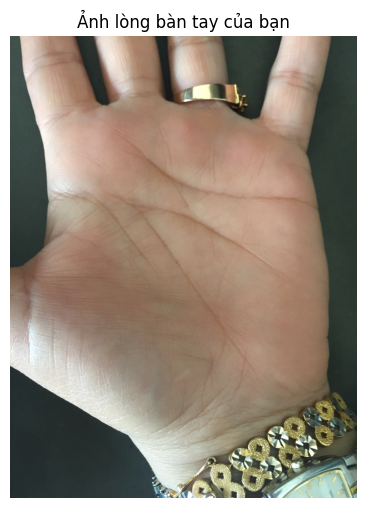


🔮 KẾT QUẢ GIẢI MÃ CHỈ TAY
──────────────────────────────
🔹 Trí tuệ   : Tư duy sắc bén       (Độ tin cậy: 63%)
🔹 Tình duyên: Thuận lợi            (Độ tin cậy: 45%)
🔹 Sức khỏe  : Sức khỏe tốt         (Độ tin cậy: 89%)


In [8]:
from google.colab import files
import matplotlib.pyplot as plt

def run_prediction():
    uploaded = files.upload()
    if not uploaded:
        return

    img_path = list(uploaded.keys())[0]
    img = cv2.imread(img_path)
    img_display = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 6))
    plt.imshow(img_display)
    plt.title("Ảnh lòng bàn tay của bạn")
    plt.axis('off')
    plt.show()

    print("\n🔮 KẾT QUẢ GIẢI MÃ CHỈ TAY")
    print("─"*30)

    for name, model in models.items():
        # Tiền xử lý ảnh giống lúc train
        crop = cv2.resize(img, IMG_SIZE)
        inp = np.expand_dims(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB) / 255.0, 0)

        # Dự đoán
        pred = model.predict(inp, verbose=0)
        cls_idx = np.argmax(pred)
        conf = np.max(pred)

        aspect = ASPECT_MAP.get(name, name)
        result = RESULT_LABELS.get(name, ["Yếu", "Trung bình", "Tốt"])[cls_idx]

        print(f"🔹 {aspect:10s}: {result:20s} (Độ tin cậy: {conf:.0%})")

run_prediction()